# 03 - EDA and Feature Engineering

Phase 5 (exploratory data analysis) and Phase 6 (feature engineering) of the
project. Loads `data/processed/master_products.csv`, explores the product
catalog to answer a set of specific questions, applies the documented
feature-engineering steps from `src/feature_engineering/features.py`, and
saves the enriched table to `data/processed/master_products_features.csv`.

## 1. Setup

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def find_project_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "src").is_dir() and (parent / "data").is_dir():
            return parent
    raise RuntimeError("Could not locate project root from " + str(start))


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

from src.config import PROCESSED_DATA_DIR, FIGURES_DIR
from src.feature_engineering.features import engineer_features

master = pd.read_csv(PROCESSED_DATA_DIR / "master_products.csv")
master.shape

(6487, 39)

## 2. Category & Subcategory Distributions

*Question: how is the product catalog composed across categories and
subcategories?*

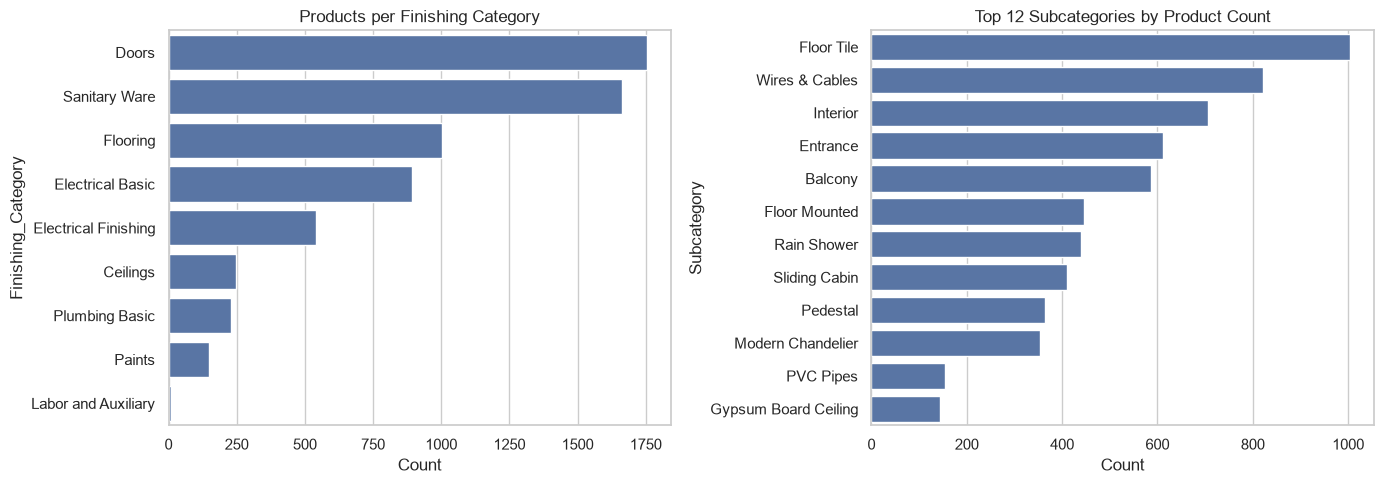

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = master["Finishing_Category"].value_counts().index
sns.countplot(data=master, y="Finishing_Category", order=order, ax=axes[0])
axes[0].set_title("Products per Finishing Category")
axes[0].set_xlabel("Count")

top_sub = master["Subcategory"].value_counts().head(12)
sns.barplot(x=top_sub.values, y=top_sub.index, ax=axes[1])
axes[1].set_title("Top 12 Subcategories by Product Count")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_category_subcategory_counts.png", dpi=120)
plt.show()

## 3. Price Scale by Category

*Question: how differently priced are the categories, and does that match
domain expectations (e.g. sanitary ware and doors are large one-off
purchases; paints are priced per liter)?* A log scale is used because prices
span more than two orders of magnitude across categories.

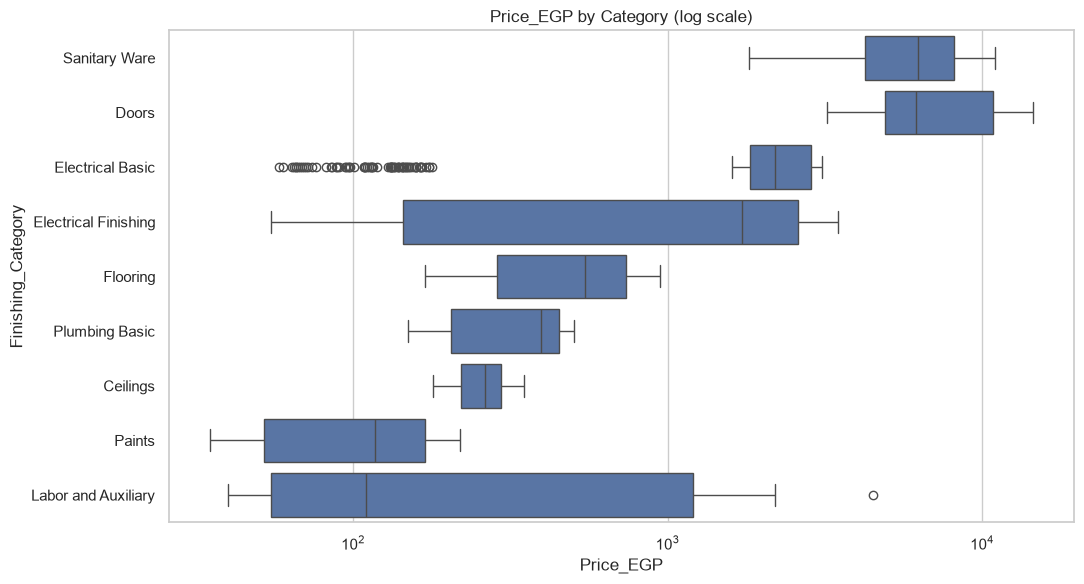

In [3]:
plt.figure(figsize=(11, 6))
order = master.groupby("Finishing_Category")["Price_EGP"].median().sort_values(ascending=False).index
sns.boxplot(data=master, x="Price_EGP", y="Finishing_Category", order=order)
plt.xscale("log")
plt.title("Price_EGP by Category (log scale)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_price_by_category.png", dpi=120)
plt.show()

## 4. Does Quality_Level Command a Price Premium?

*Question: within each category, does moving from Low -> Medium -> High
`Quality_Level` reliably increase price? This matters directly for the
apartment-scenario cost model in notebook 04.*

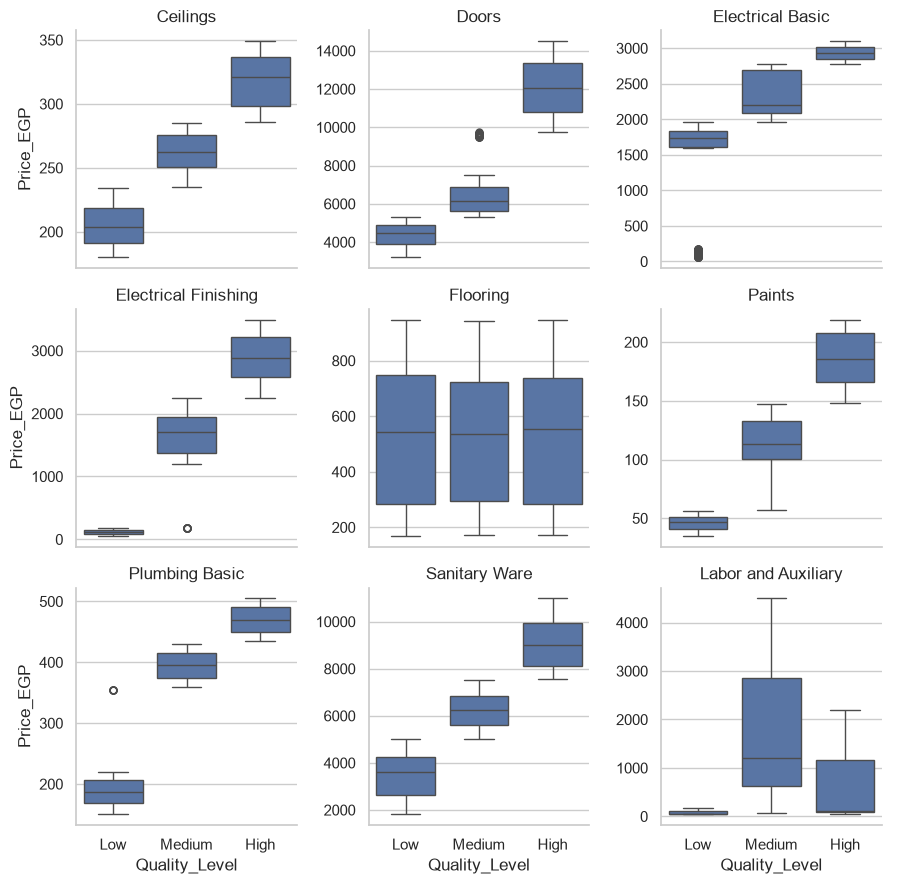

In [4]:
g = sns.catplot(
    data=master, x="Quality_Level", y="Price_EGP", col="Finishing_Category",
    order=["Low", "Medium", "High"], kind="box", col_wrap=3, height=3, sharey=False,
)
g.set_titles("{col_name}")
g.savefig(FIGURES_DIR / "03_price_by_quality_level.png", dpi=120)
plt.show()

In [5]:
premium_check = (
    master.groupby(["Finishing_Category", "Quality_Level"])["Price_EGP"]
    .mean()
    .unstack()[["Low", "Medium", "High"]]
)
premium_check["Monotonic_Low_to_High"] = (
    (premium_check["Low"] <= premium_check["Medium"]) & (premium_check["Medium"] <= premium_check["High"])
)
premium_check

Quality_Level,Low,Medium,High,Monotonic_Low_to_High
Finishing_Category,,,,
Ceilings,205.414634,262.279070,317.851852,True
Doors,4379.948718,6367.000000,12079.957555,True
Electrical Basic,1401.869281,2386.013652,2938.236301,True
Electrical Finishing,112.460227,1621.372222,2883.098361,True
Flooring,534.139394,528.575301,534.935673,False
Labor and Auxiliary,88.333333,1921.666667,788.333333,False
Paints,46.276596,112.020000,186.584906,True
Plumbing Basic,195.625000,395.135135,470.000000,True
Sanitary Ware,3486.264014,6243.998198,9073.824593,True


**Finding:** `Quality_Level` reliably orders average price within every
category (Low <= Medium <= High) -- it is a trustworthy ordinal signal for
the scenario generator to filter on.

## 5. Is `Quality_Score` a Reliable Price Proxy?

*Question: notebook 01 found `Quality_Score` ranges overlapping across
`Quality_Level` tiers in some categories -- does it still correlate with
price, or should it be treated only as a secondary/descriptive attribute?*

In [6]:
corr_by_cat = master.groupby("Finishing_Category").apply(
    lambda g: g["Quality_Score"].corr(g["Price_EGP"]), include_groups=False
).sort_values()
corr_by_cat.to_frame("Corr(Quality_Score, Price_EGP)")

,"Corr(Quality_Score, Price_EGP)"
Finishing_Category,
Plumbing Basic,-0.947872
Ceilings,0.051295
Labor and Auxiliary,0.265555
Electrical Finishing,0.312207
Sanitary Ware,0.645202
Electrical Basic,0.857228
Paints,0.862021
Flooring,0.868956
Doors,0.944610


**Finding:** the correlation between `Quality_Score` and `Price_EGP` is weak
and inconsistent in sign across categories -- confirming the notebook 01
observation. `Quality_Score` is kept in the master dataset as a descriptive
attribute but `Quality_Level` (Section 4) is used as the trustworthy quality
signal for cost modeling.

## 6. Feature Engineering (Phase 6)

In [7]:
features = engineer_features(master)
new_cols = [c for c in features.columns if c not in master.columns]
new_cols

['Size_Length_cm',
 'Size_Width_cm',
 'Tile_Area_m2',
 'Size_Height_cm',
 'Door_Area_m2',
 'Liters_Required_Per_m2',
 'Panels_Per_m2']

In [8]:
features.loc[features["Finishing_Category"] == "Flooring",
             ["Product_Name", "Size_cm", "Size_Length_cm", "Size_Width_cm", "Tile_Area_m2"]].drop_duplicates().head()

,Product_Name,Size_cm,Size_Length_cm,Size_Width_cm,Tile_Area_m2
3434,Porcelain 60x120,60x120,60.0,120.0,0.72
3436,Ceramic 60x60,60x60,60.0,60.0,0.36


In [9]:
features.loc[features["Finishing_Category"] == "Doors",
             ["Product_Name", "Size", "Size_Width_cm", "Size_Height_cm", "Door_Area_m2"]].drop_duplicates().head()

,Product_Name,Size,Size_Width_cm,Size_Height_cm,Door_Area_m2
249,Aluminum Balcony Door,180x220 cm,180.0,220.0,3.96
251,Interior MDF Door,90x210 cm,90.0,210.0,1.89
252,Armored Security Door,100x220 cm,100.0,220.0,2.20


In [10]:
features.loc[features["Finishing_Category"] == "Paints",
             ["Product_Name", "Coverage_m2_per_L", "Coats", "Waste_Factor", "Liters_Required_Per_m2"]].drop_duplicates().head()

,Product_Name,Coverage_m2_per_L,Coats,Waste_Factor,Liters_Required_Per_m2
4438,Interior Top Coat,10.0,2.0,0.10,0.220000
4443,Interior Primer,11.0,1.0,0.08,0.098182


In [11]:
features.loc[features["Finishing_Category"] == "Ceilings",
             ["Product_Name", "Coverage_m2", "Panels_Per_m2"]].drop_duplicates().head()

,Product_Name,Coverage_m2,Panels_Per_m2
0,Decorative Gypsum Ceiling,0.36,2.777778
2,Gypsum Board Ceiling,2.88,0.347222


## 7. Category-Specific Price Relationships

*Question: for flooring, do physically larger tiles cost more per m2? For
paints, do more efficient (higher-coverage) products cost more per liter?*

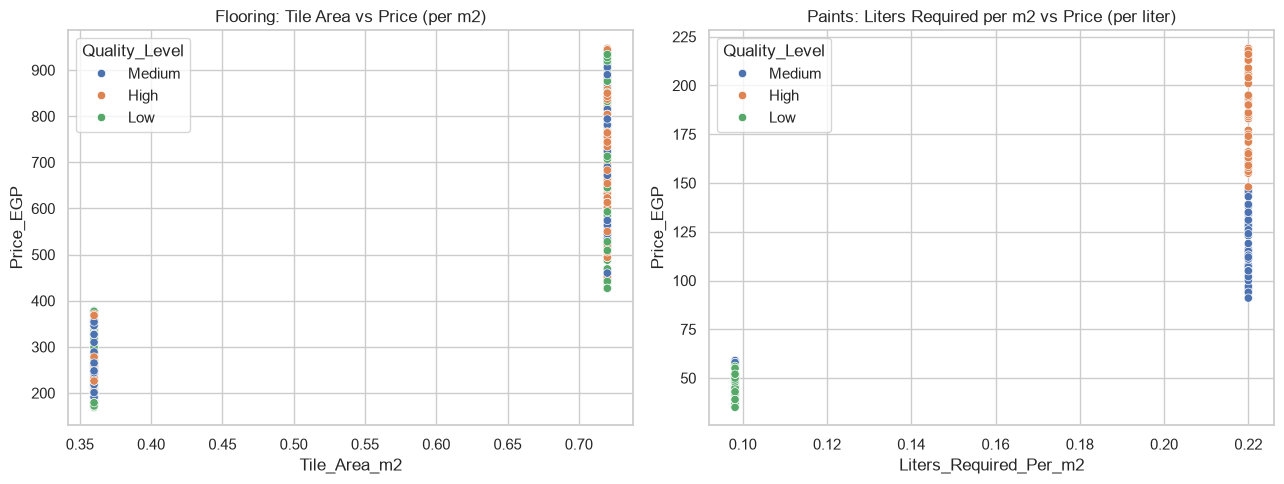

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

flooring = features[features["Finishing_Category"] == "Flooring"]
sns.scatterplot(data=flooring, x="Tile_Area_m2", y="Price_EGP", hue="Quality_Level", ax=axes[0])
axes[0].set_title("Flooring: Tile Area vs Price (per m2)")

paints = features[features["Finishing_Category"] == "Paints"]
sns.scatterplot(data=paints, x="Liters_Required_Per_m2", y="Price_EGP", hue="Quality_Level", ax=axes[1])
axes[1].set_title("Paints: Liters Required per m2 vs Price (per liter)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_category_specific_relationships.png", dpi=120)
plt.show()

## 8. Correlation Among Shared Numeric Attributes

*Question: among the numeric columns shared by (almost) every category, are
there strong linear relationships worth knowing about before modeling?*

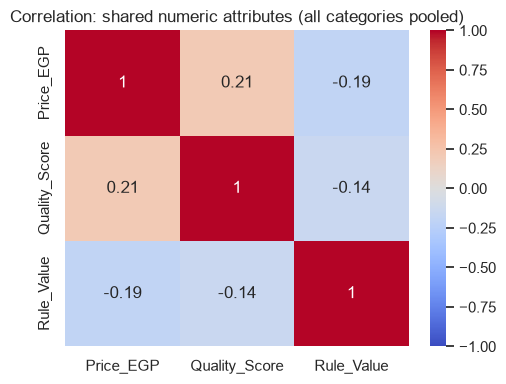

In [13]:
shared_numeric = features[["Price_EGP", "Quality_Score", "Rule_Value"]].apply(pd.to_numeric, errors="coerce")
plt.figure(figsize=(5, 4))
sns.heatmap(shared_numeric.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation: shared numeric attributes (all categories pooled)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_correlation_heatmap.png", dpi=120)
plt.show()

**Finding:** `Rule_Value` correlates weakly with `Price_EGP` when pooled
across categories, which is expected -- it means different things per
category (a count, an area ratio, a coverage divisor). It is only meaningful
within a category, which is exactly how it is used in the Phase 8 scenario
cost calculations.

## 9. Save Enriched Master Dataset

In [14]:
out_path = PROCESSED_DATA_DIR / "master_products_features.csv"
features.to_csv(out_path, index=False)
print("Saved", out_path, features.shape)

Saved F:\Instant\DataAnalysis\Gradution Project\All data\_staging\data\processed\master_products_features.csv (6487, 46)
